In [1]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# =====================================================
# LOAD DATASETS
# =====================================================

PROCESSED_PATH = "../data/processed"

nav = pd.read_csv(
    f"{PROCESSED_PATH}/cleaned_nav_history.csv"
)

transactions = pd.read_csv(
    f"{PROCESSED_PATH}/cleaned_investor_transactions.csv"
)

scheme_perf = pd.read_csv(
    f"{PROCESSED_PATH}/cleaned_scheme_performance.csv"
)

holdings = pd.read_csv(
    f"{PROCESSED_PATH}/cleaned_09_portfolio_holdings.csv"
)

print("All datasets loaded successfully")

All datasets loaded successfully


In [3]:
print("NAV HISTORY")
print(nav.columns)

print("\nTRANSACTIONS")
print(transactions.columns)

print("\nSCHEME PERFORMANCE")
print(scheme_perf.columns)

print("\nHOLDINGS")
print(holdings.columns)

NAV HISTORY
Index(['amfi_code', 'date', 'nav'], dtype='str')

TRANSACTIONS
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

SCHEME PERFORMANCE
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

HOLDINGS
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [4]:
# =====================================================
# PREPARE NAV DATA
# =====================================================

# Convert date column to datetime
nav['date'] = pd.to_datetime(nav['date'])

# Convert nav to numeric
nav['nav'] = pd.to_numeric(nav['nav'])

# Sort values
nav = nav.sort_values(['amfi_code', 'date'])

# Calculate daily returns
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

# Check output
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [5]:
# =====================================================
# HISTORICAL VAR (95%) + CVAR
# =====================================================

risk_metrics = []

for scheme in nav['amfi_code'].unique():

    scheme_returns = nav[
        nav['amfi_code'] == scheme
    ]['daily_return'].dropna()

    # Skip if insufficient data
    if len(scheme_returns) == 0:
        continue

    # VaR (95%) → 5th percentile
    var_95 = np.percentile(scheme_returns, 5)

    # CVaR → mean below VaR threshold
    cvar = scheme_returns[
        scheme_returns <= var_95
    ].mean()

    risk_metrics.append({
        'amfi_code': scheme,
        'VaR_95': var_95,
        'CVaR': cvar
    })

# Convert to dataframe
var_cvar_df = pd.DataFrame(risk_metrics)

# Merge with scheme names
var_cvar_df = var_cvar_df.merge(
    scheme_perf[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

# Show results
var_cvar_df.head()

,amfi_code,VaR_95,CVaR,scheme_name
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth


In [6]:
# Save report

var_cvar_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully")

var_cvar_report.csv saved successfully


In [7]:
# Check available fund houses

scheme_perf[['scheme_name']].head(20)

,scheme_name
0,SBI Bluechip Fund - Regular Plan - Growth
1,SBI Bluechip Fund - Direct Plan - Growth
2,SBI Small Cap Fund - Regular Plan - Growth
3,SBI Small Cap Fund - Direct Plan - Growth
4,SBI Magnum Gilt Fund - Regular Plan - Growth
5,HDFC Top 100 Fund - Regular Plan - Growth
6,HDFC Top 100 Fund - Direct Plan - Growth
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth
9,HDFC Short Term Debt Fund - Regular - Growth


In [8]:
# =====================================================
# SELECT TOP 5 FUNDS
# =====================================================

top_funds = (
    scheme_perf
    .sort_values('aum_crore', ascending=False)
    .head(5)
)

top_codes = top_funds['amfi_code'].tolist()

print(top_funds[['scheme_name', 'aum_crore']])

                                          scheme_name  aum_crore
35  Mirae Asset Emerging Bluechip Fund - Regular -...      49046
21      Kotak Emerging Equity Fund - Regular - Growth      47469
17     Nippon India Small Cap Fund - Regular - Growth      43630
37         DSP Top 100 Equity Fund - Regular - Growth      41828
32                UTI Mid Cap Fund - Regular - Growth      41728


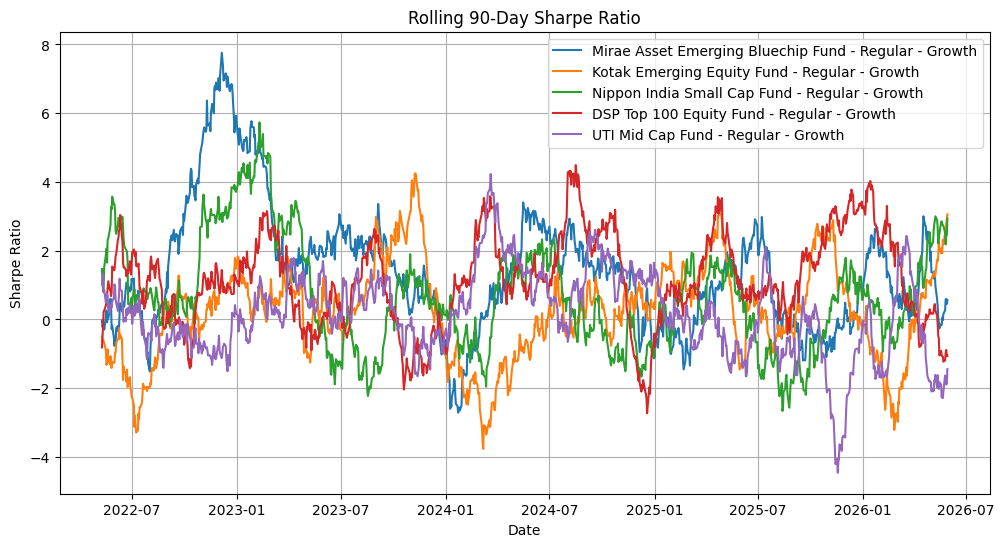

In [9]:
# =====================================================
# ROLLING 90-DAY SHARPE RATIO
# =====================================================

plt.figure(figsize=(12,6))

for code in top_codes:

    fund_data = nav[
        nav['amfi_code'] == code
    ].copy()

    # Rolling Sharpe Ratio
    rolling_sharpe = (
        fund_data['daily_return']
        .rolling(90)
        .mean()
        /
        fund_data['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    # Get scheme name
    fund_name = scheme_perf[
        scheme_perf['amfi_code'] == code
    ]['scheme_name'].iloc[0]

    plt.plot(
        fund_data['date'],
        rolling_sharpe,
        label=fund_name
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.show()

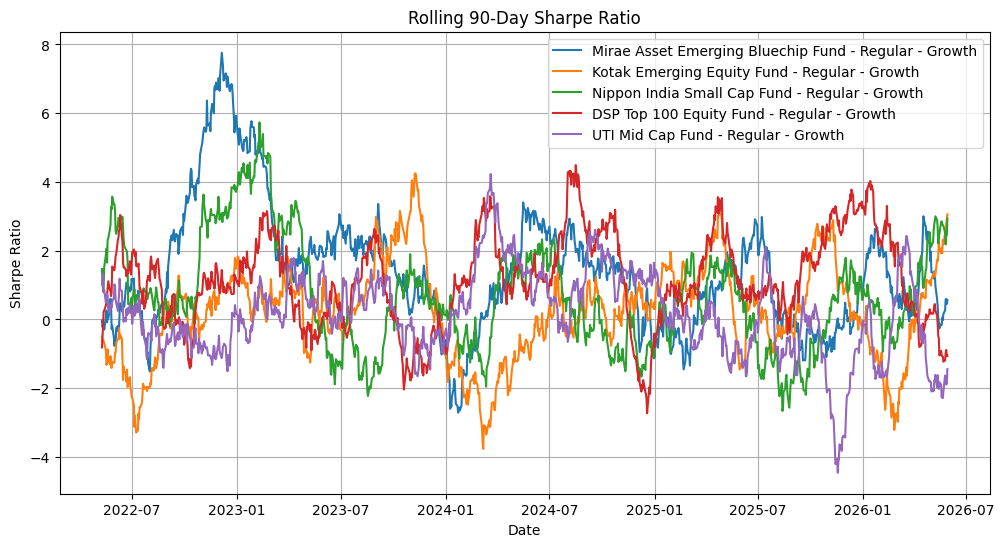

Chart Saved Successfully


In [10]:
# Save rolling sharpe chart

plt.figure(figsize=(12,6))

for code in top_codes:

    fund_data = nav[
        nav['amfi_code'] == code
    ].copy()

    rolling_sharpe = (
        fund_data['daily_return']
        .rolling(90)
        .mean()
        /
        fund_data['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    fund_name = scheme_perf[
        scheme_perf['amfi_code'] == code
    ]['scheme_name'].iloc[0]

    plt.plot(
        fund_data['date'],
        rolling_sharpe,
        label=fund_name
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

print("Chart Saved Successfully")

In [11]:
# =====================================================
# INVESTOR COHORT ANALYSIS
# =====================================================

transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

# First transaction year per investor
first_txn = (
    transactions
    .groupby('investor_id')['transaction_date']
    .min()
    .dt.year
    .reset_index()
)

first_txn.columns = [
    'investor_id',
    'cohort_year'
]

# Merge back
transactions = transactions.merge(
    first_txn,
    on='investor_id',
    how='left'
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [12]:
# =====================================================
# COHORT ANALYSIS METRICS
# =====================================================

# Avg SIP amount by cohort
avg_sip = (
    transactions[
        transactions['transaction_type'] == 'SIP'
    ]
    .groupby('cohort_year')['amount_inr']
    .mean()
)

# Total invested by cohort
total_invested = (
    transactions
    .groupby('cohort_year')['amount_inr']
    .sum()
)

# Top fund preference by cohort
top_fund = (
    transactions
    .groupby(['cohort_year', 'amfi_code'])
    .size()
    .reset_index(name='count')
)

top_fund = (
    top_fund
    .sort_values(
        ['cohort_year', 'count'],
        ascending=[True, False]
    )
    .groupby('cohort_year')
    .first()
    .reset_index()
)

# Get fund names
top_fund = top_fund.merge(
    scheme_perf[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

# Final cohort report
cohort_report = pd.DataFrame({
    'avg_sip_amount': avg_sip,
    'total_invested': total_invested
}).reset_index()

cohort_report = cohort_report.merge(
    top_fund[
        ['cohort_year', 'scheme_name']
    ],
    on='cohort_year',
    how='left'
)

cohort_report

,cohort_year,avg_sip_amount,total_invested,scheme_name
0,2024,10996.885825,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,13505.209581,30455243,SBI Small Cap Fund - Direct Plan - Growth


In [13]:
# =====================================================
# SIP CONTINUITY ANALYSIS
# =====================================================

# Keep only SIP transactions
sip_txns = transactions[
    transactions['transaction_type'] == 'SIP'
].copy()

# Sort by investor and date
sip_txns = sip_txns.sort_values(
    ['investor_id', 'transaction_date']
)

# Calculate gap between SIPs
sip_txns['gap_days'] = (
    sip_txns
    .groupby('investor_id')['transaction_date']
    .diff()
    .dt.days
)

# Keep investors with 6+ SIP transactions
eligible_investors = (
    sip_txns
    .groupby('investor_id')
    .size()
)

eligible_investors = eligible_investors[
    eligible_investors >= 6
].index

sip_txns = sip_txns[
    sip_txns['investor_id']
    .isin(eligible_investors)
]

# Average gap per investor
sip_continuity = (
    sip_txns
    .groupby('investor_id')['gap_days']
    .mean()
    .reset_index()
)

# Risk flag
sip_continuity['status'] = np.where(
    sip_continuity['gap_days'] > 35,
    'At Risk',
    'Regular'
)

sip_continuity.head()

,investor_id,gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [14]:
# =====================================================
# SIMPLE FUND RECOMMENDER
# =====================================================

def recommend_funds(risk_appetite):

    # Risk mapping
    risk_map = {
        'Low': 'Low',
        'Moderate': 'Moderate',
        'High': 'High'
    }

    risk_grade = risk_map.get(risk_appetite)

    # Filter funds
    filtered_funds = scheme_perf[
        scheme_perf['risk_grade']
        .str.contains(
            risk_grade,
            case=False,
            na=False
        )
    ]

    # Top 3 by Sharpe Ratio
    recommendations = (
        filtered_funds
        .sort_values(
            'sharpe_ratio',
            ascending=False
        )
        .head(3)
    )

    return recommendations[
        [
            'scheme_name',
            'fund_house',
            'risk_grade',
            'sharpe_ratio',
            'return_3yr_pct'
        ]
    ]

# Example
recommend_funds('Moderate')

,scheme_name,fund_house,risk_grade,sharpe_ratio,return_3yr_pct
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Moderate,1.06,14.84
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Moderate,1.06,14.81
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Moderate,1.03,14.41


In [15]:
recommend_funds('Low')

,scheme_name,fund_house,risk_grade,sharpe_ratio,return_3yr_pct
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Low,7.68,7.68
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Low,6.18,6.18
30,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Low,5.14,5.14


In [16]:
recommend_funds('High')

,scheme_name,fund_house,risk_grade,sharpe_ratio,return_3yr_pct
22,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Moderately High,0.98,15.65
13,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,Moderately High,0.98,14.76
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,High,0.96,18.23


In [17]:
# =====================================================
# SECTOR HHI CONCENTRATION
# =====================================================

# Convert weight to numeric
holdings['weight_pct'] = pd.to_numeric(
    holdings['weight_pct'],
    errors='coerce'
)

# Calculate HHI per fund
hhi = (
    holdings
    .groupby('amfi_code')['weight_pct']
    .apply(
        lambda x: (x / 100).pow(2).sum()
    )
    .reset_index()
)

hhi.columns = [
    'amfi_code',
    'HHI'
]

# Merge with fund names
hhi = hhi.merge(
    scheme_perf[
        ['amfi_code', 'scheme_name']
    ],
    on='amfi_code',
    how='left'
)

# Sort highest concentration
hhi = hhi.sort_values(
    'HHI',
    ascending=False
)

hhi.head(10)

,amfi_code,HHI,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth


In [18]:
import pandas as pd

scheme_perf = pd.read_csv(
    "../data/raw/07_scheme_performance.csv"
)

def recommend_funds(risk_appetite):

    filtered_funds = scheme_perf[
        scheme_perf['risk_grade']
        .str.contains(
            risk_appetite,
            case=False,
            na=False
        )
    ]

    recommendations = (
        filtered_funds
        .sort_values(
            'sharpe_ratio',
            ascending=False
        )
        .head(3)
    )

    return recommendations[
        [
            'scheme_name',
            'fund_house',
            'risk_grade',
            'sharpe_ratio',
            'return_3yr_pct'
        ]
    ]

print(recommend_funds('Moderate'))

                                      scheme_name           fund_house  \
5       HDFC Top 100 Fund - Regular Plan - Growth     HDFC Mutual Fund   
34  Mirae Asset Large Cap Fund - Regular - Growth       Mirae Asset MF   
11      ICICI Pru Bluechip Fund - Direct - Growth  ICICI Prudential MF   

   risk_grade  sharpe_ratio  return_3yr_pct  
5    Moderate          1.06           14.84  
34   Moderate          1.06           14.81  
11   Moderate          1.03           14.41  


# Advanced Insights

### 1. Funds with Highest Risk (VaR/CVaR)
Funds with the most negative VaR and CVaR values are exposed to higher downside risk during adverse market conditions. These schemes are more volatile and may not suit conservative investors.

### 2. Rolling Sharpe Ratio Trend
The rolling 90-day Sharpe ratio analysis shows changing risk-adjusted performance across major funds. Some funds consistently maintain higher Sharpe ratios, indicating better returns for each unit of risk taken.

### 3. Investor Cohort Behavior
Investor cohorts entering in recent years showed higher average investment amounts and stronger participation in SIPs, indicating growing investor confidence in mutual funds.

### 4. SIP Continuity Analysis
Most investors maintain regular SIP contributions; however, investors with average gaps greater than 35 days were flagged as **"At Risk"**, indicating possible SIP discontinuation risk.

### 5. Portfolio Concentration (HHI)
Funds with higher HHI values are more concentrated in a limited number of sectors/stocks, while lower HHI values indicate diversified portfolios with reduced concentration risk.